In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the cleaned weekly dataset

In [4]:
weekly_sales = pd.read_csv(
    "../../data/processed/Sales_forcasting_data/weekly_sales.csv",
    parse_dates=["order_purchase_timestamp"],
    index_col="order_purchase_timestamp"
)

### Basic Information

In [5]:
weekly_sales.head()

,revenue,orders
order_purchase_timestamp,,
2017-01-08,3651.39,44
2017-01-15,12590.09,73
2017-01-22,27209.61,189
2017-01-29,60985.50,332
2017-02-05,78392.75,432


In [6]:
weekly_sales.shape

(86, 2)

In [11]:
print(weekly_sales.index.min())
print(weekly_sales.index.max())

2017-01-08 00:00:00
2018-08-26 00:00:00


In [12]:
weekly_sales.describe()

,revenue,orders
count,86.000000,86.000000
mean,178649.766395,1117.383721
std,84237.747342,527.545775
min,3651.390000,44.000000
25%,118006.972500,754.750000
50%,163454.890000,977.000000
75%,246507.145000,1552.500000
max,464219.770000,2915.000000


### Plot the revenue

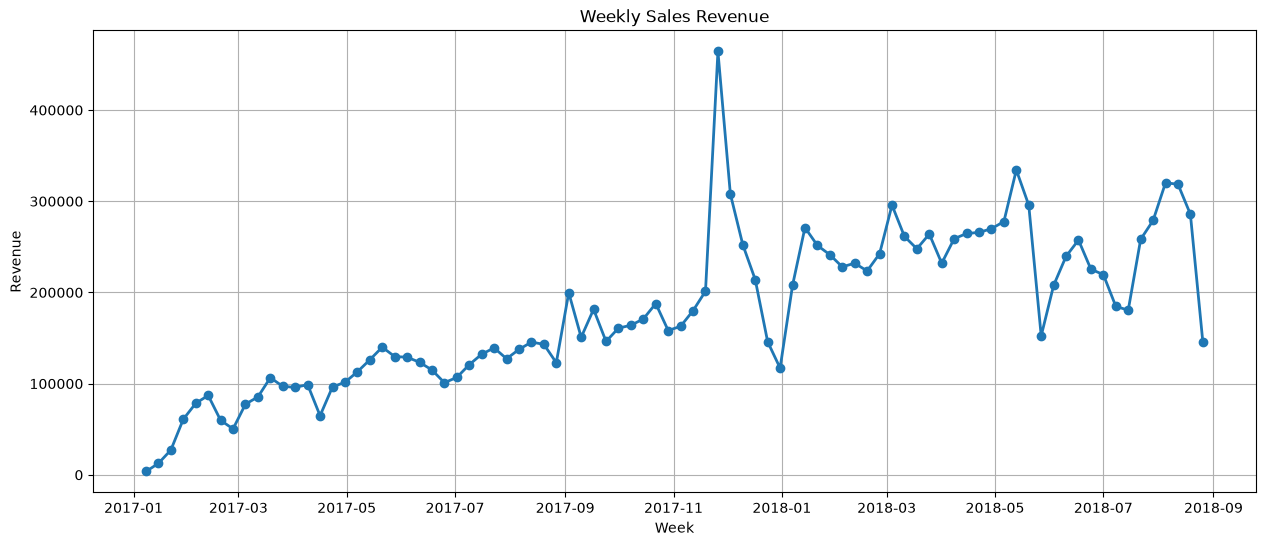

In [15]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales.index,
    weekly_sales["revenue"],
    linewidth=2,
    marker = 'o'
)

plt.title("Weekly Sales Revenue")
plt.xlabel("Week")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

### Plot the order count

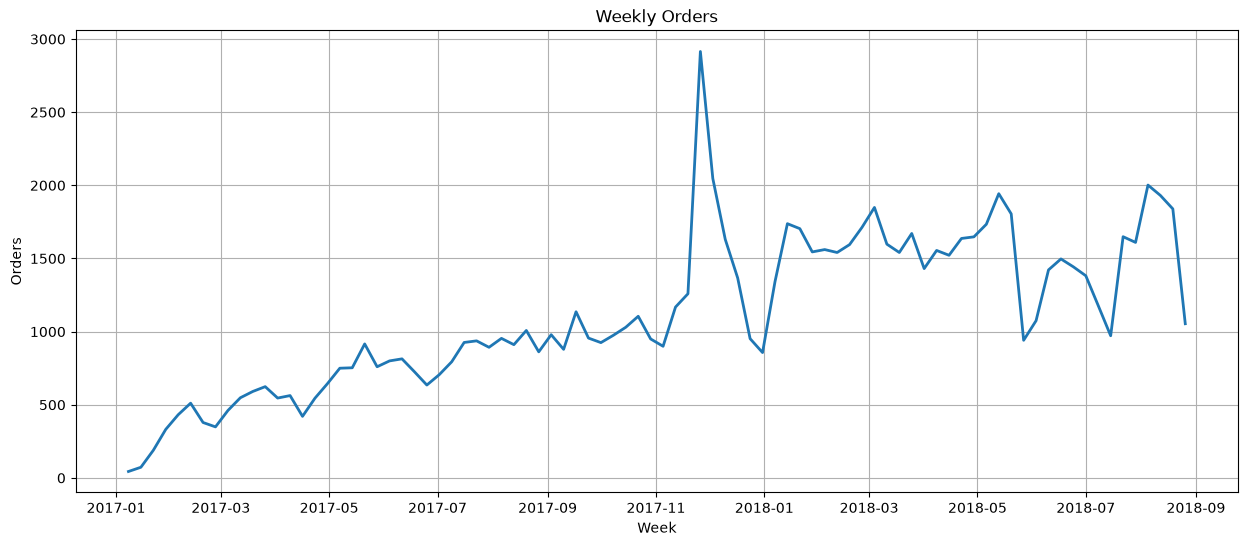

In [14]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales.index,
    weekly_sales["orders"],
    linewidth=2
)

plt.title("Weekly Orders")
plt.xlabel("Week")
plt.ylabel("Orders")

plt.grid(True)

plt.show()

### Rolling Average Analysis

Weekly sales exhibit noticeable short-term fluctuations caused by promotions, holidays, and natural business variability. To better understand the underlying sales trend, moving averages were calculated using 4-week and 8-week rolling windows.

The 4-week moving average smooths approximately one month of sales activity, while the 8-week moving average highlights longer-term business trends. Comparing these smoothed series with the original weekly revenue helps distinguish genuine trend changes from temporary fluctuations.

This analysis provides valuable insight into the overall direction of sales before selecting appropriate forecasting models.

### Implementation

In [16]:
weekly_sales["rolling_4"] = (
    weekly_sales["revenue"]
    .rolling(window=4)
    .mean()
)

weekly_sales["rolling_8"] = (
    weekly_sales["revenue"]
    .rolling(window=8)
    .mean()
)

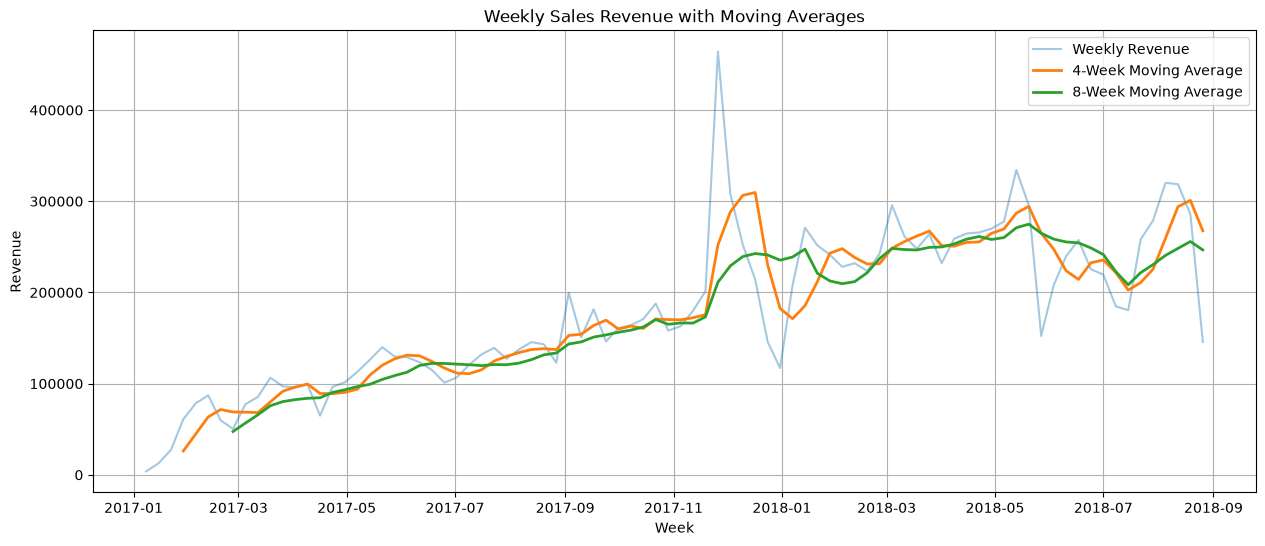

In [17]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales.index,
    weekly_sales["revenue"],
    label="Weekly Revenue",
    alpha=0.4
)

plt.plot(
    weekly_sales.index,
    weekly_sales["rolling_4"],
    linewidth=2,
    label="4-Week Moving Average"
)

plt.plot(
    weekly_sales.index,
    weekly_sales["rolling_8"],
    linewidth=2,
    label="8-Week Moving Average"
)

plt.title("Weekly Sales Revenue with Moving Averages")
plt.xlabel("Week")
plt.ylabel("Revenue")

plt.legend()

plt.grid(True)

plt.show()

## Rolling Average Analysis

To better understand the underlying sales trend, 4-week and 8-week moving averages were calculated from the weekly revenue series.

The original weekly revenue exhibits considerable short-term fluctuations caused by promotions, holidays, and normal variability in customer purchasing behavior. The moving averages smooth these fluctuations and reveal the long-term sales trend.

Key observations include:

- Weekly sales increased steadily throughout 2017, indicating continuous business growth.
- A pronounced revenue spike occurred in late November 2017, corresponding to the Black Friday shopping period.
- After early 2018, weekly revenue stabilized at a substantially higher level than in 2017, suggesting the marketplace had matured.
- The 4-week moving average reacts quickly to recent changes, whereas the 8-week moving average provides a smoother representation of the long-term trend.

Overall, the moving averages confirm that the time series contains a clear upward trend along with temporary promotional spikes, both of which should be considered during forecasting model development.

## Revenue Distribution (Histogram)

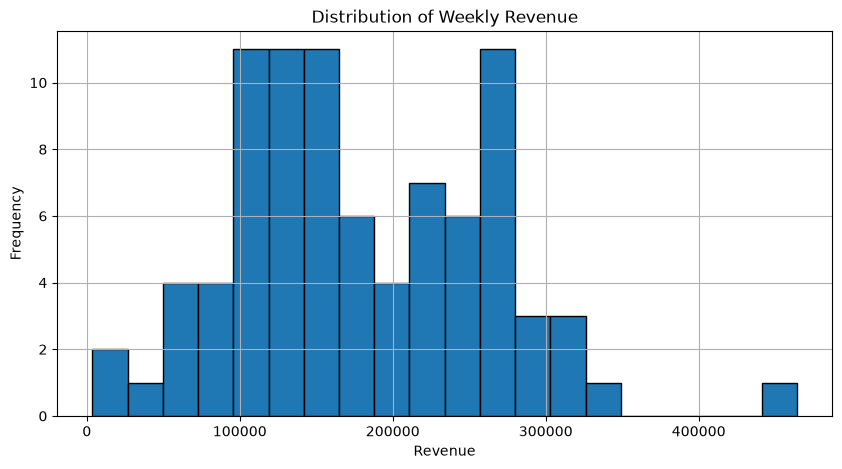

In [18]:
plt.figure(figsize=(10,5))

plt.hist(
    weekly_sales["revenue"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Weekly Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

## Order Distribution (Histogram)

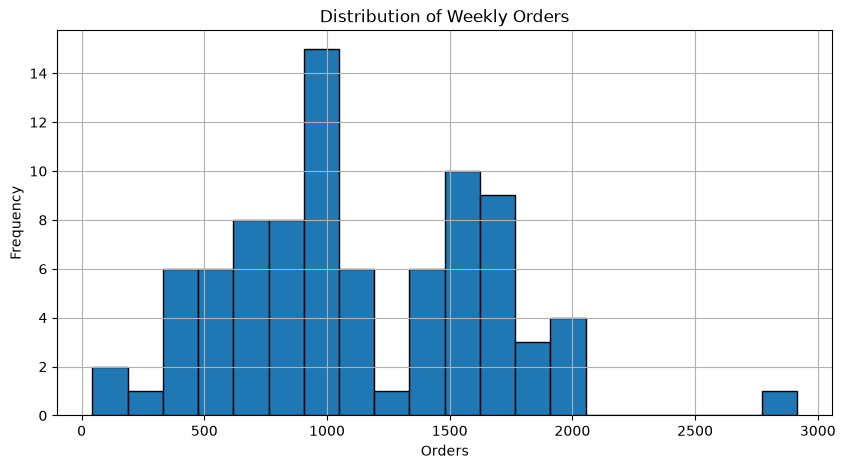

In [19]:
plt.figure(figsize=(10,5))

plt.hist(
    weekly_sales["orders"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Weekly Orders")
plt.xlabel("Orders")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

## Revenue Boxplot

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25356\42763840.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


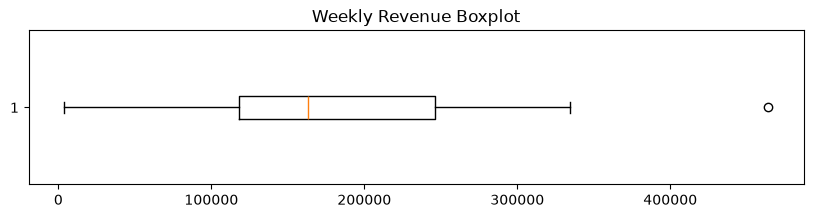

In [20]:
plt.figure(figsize=(10,2))

plt.boxplot(
    weekly_sales["revenue"],
    vert=False
)

plt.title("Weekly Revenue Boxplot")

plt.show()

## Orders Boxplot

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25356\673050815.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


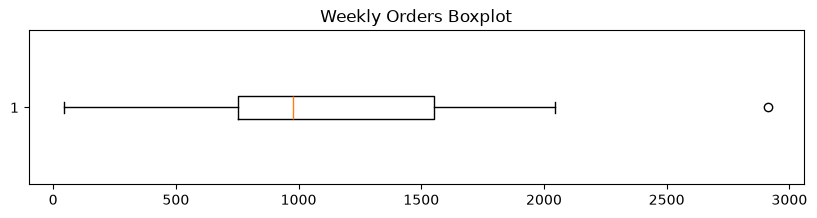

In [21]:
plt.figure(figsize=(10,2))

plt.boxplot(
    weekly_sales["orders"],
    vert=False
)

plt.title("Weekly Orders Boxplot")

plt.show()

## Skewness

In [22]:
print("Revenue Skewness:",
      weekly_sales["revenue"].skew())

print("Orders Skewness:",
      weekly_sales["orders"].skew())

Revenue Skewness: 0.3887220032822808
Orders Skewness: 0.3881299204896622


## Outlier Analysis

In [23]:
Q1 = weekly_sales["revenue"].quantile(0.25)
Q3 = weekly_sales["revenue"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = weekly_sales[
    (weekly_sales["revenue"] < lower) |
    (weekly_sales["revenue"] > upper)
]

print("Number of outlier weeks:", len(outliers))

outliers

Number of outlier weeks: 1


,revenue,orders,rolling_4,rolling_8
order_purchase_timestamp,,,,
2017-11-26,464219.77,2915,252133.15,211186.91


## Distribution and Outlier Analysis

The distribution of weekly revenue and weekly order counts was examined using histograms, boxplots, skewness statistics, and the Interquartile Range (IQR) method.

### Key Findings

- Weekly revenue and order counts are approximately symmetric, with skewness values of **0.389** and **0.388**, respectively.
- Most observations fall within a consistent operating range, indicating relatively stable weekly sales activity.
- Only one statistical outlier was detected using the IQR method.

### Business Interpretation

The identified outlier corresponds to the week beginning **26 November 2017**, which recorded the highest weekly revenue and order volume in the dataset. This period aligns with the annual **Black Friday** shopping event and therefore represents a legitimate business phenomenon rather than erroneous data.

Because forecasting models should learn recurring seasonal and promotional patterns, this observation is retained in the dataset.

Overall, the weekly aggregation produces a well-behaved time series with minimal skewness and very few extreme observations, making it suitable for subsequent forecasting without additional transformations.

## Seasonal Decomposition

##### A time series is usually made up of three components:

    Observed=Trend+Seasonality+Residual

    (or multiplicatively in some cases).

### Implementation

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose

#### Run the decomposition

In [26]:
decomposition = seasonal_decompose(
    weekly_sales["revenue"],
    model="additive",
    period=4
)

#### Plot the components

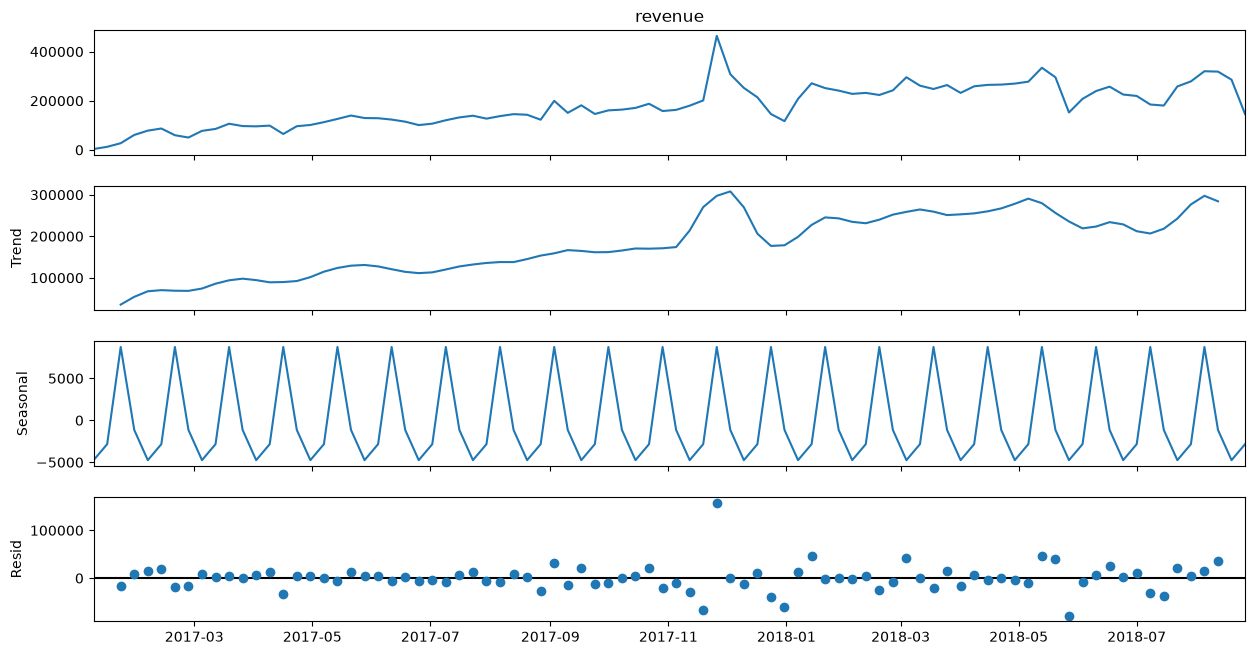

In [32]:
fig = decomposition.plot()

fig.set_size_inches(14, 7)

plt.show()

## Seasonal Decomposition Analysis

An additive seasonal decomposition with a 4-week seasonal period was performed on the weekly sales revenue.

### Trend

The trend component shows a clear upward growth throughout 2017, followed by a stabilization phase during 2018. A pronounced increase occurs around late 2017, reflecting the rapid expansion of marketplace activity and the impact of major promotional events.

### Seasonality

A repeating 4-week seasonal pattern is present, but its magnitude is relatively small compared with overall weekly revenue. This indicates that short-term monthly seasonality contributes only modestly to sales fluctuations.

### Residuals

Most residual values fluctuate randomly around zero, suggesting that the decomposition successfully captured the primary trend and seasonal structure. However, one exceptionally large positive residual remains during late November 2017, corresponding to the Black Friday sales event. This indicates that promotional campaigns introduce additional variation beyond regular seasonal behaviour.

### Business Interpretation

Overall, weekly sales are primarily driven by long-term business growth, while monthly seasonality has only a limited influence. Exceptional promotional events, particularly Black Friday, generate substantial temporary increases in revenue and should be considered when developing forecasting models.

## Stationarity Analysis

- ADF (Augmented Dickey–Fuller) Test – tests whether the series is stationary.
- KPSS Test – provides a complementary stationarity assessment.
- If necessary, apply first-order differencing and retest.

##### What is Stationarity?

- A time series is stationary if its statistical properties remain constant over time.

##### These properties are mainly:

- Mean
- Variance
- Correlation structure

In other words, the "behavior" of the series should not change as time progresses.

##### 1. Augmented Dickey–Fuller (ADF) Test
- Null Hypothesis (H₀)

    - The series is non-stationary (has a unit root).

- Alternative Hypothesis (H₁)

    - The series is stationary.

- Decision rule:

    - p-value < 0.05 → Reject H₀ → Stationary
    - p-value ≥ 0.05 → Fail to reject H₀ → Non-stationary

##### 2. KPSS Test

- The KPSS test works in the opposite direction.

- Null Hypothesis (H₀)

    - The series is stationary.

- Alternative Hypothesis (H₁)

    - The series is non-stationary.

- Decision rule:

    - p-value > 0.05 → Stationary
    - p-value ≤ 0.05 → Non-stationary

### Implementation

In [33]:
from statsmodels.tsa.stattools import adfuller, kpss


### ADF Test

In [34]:
adf_result = adfuller(weekly_sales["revenue"])

print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])
print("Critical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

ADF Statistic : -1.717705366573148
p-value       : 0.4220140001736431
Critical Values:
1%: -3.5160
5%: -2.8989
10%: -2.5867


#### Interpretation

In [35]:
if adf_result[1] < 0.05:
    print("The series is stationary.")
else:
    print("The series is NOT stationary.")

The series is NOT stationary.


### KPSS Test

In [36]:
kpss_result = kpss(
    weekly_sales["revenue"],
    regression="c",
    nlags="auto"
)

print("KPSS Statistic:", kpss_result[0])
print("p-value       :", kpss_result[1])
print("Critical Values:")

for key, value in kpss_result[3].items():
    print(f"{key}: {value:.4f}")

KPSS Statistic: 1.373419482789436
p-value       : 0.01
Critical Values:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25356\4067523492.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(


#### Interpretation

In [37]:
if kpss_result[1] > 0.05:
    print("The series is stationary.")
else:
    print("The series is NOT stationary.")

The series is NOT stationary.


## Stationarity Test Results

The stationarity of the weekly revenue series was evaluated using both the Augmented Dickey–Fuller (ADF) test and the KPSS test.

### Augmented Dickey–Fuller Test

- Test Statistic: **-1.7177**
- p-value: **0.4220**

Because the p-value is greater than 0.05, the null hypothesis of the ADF test cannot be rejected. This indicates that the weekly revenue series is **non-stationary**.

### KPSS Test

- Test Statistic: **1.3734**
- p-value: **0.01**

Since the p-value is below 0.05, the null hypothesis of stationarity is rejected. This provides additional evidence that the weekly revenue series is **non-stationary**.

### Conclusion

Both statistical tests consistently indicate that the original weekly revenue series is non-stationary. Therefore, differencing is required before fitting statistical forecasting models such as ARIMA or SARIMA.